In [19]:
%pip install pandas

import pandas as pd
import numpy as np
import datetime as dt
%pip install yfinance

import yfinance as yf


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
tataelxsi = yf.Ticker("TATAELXSI.NS")
tataelxsi.info


{'address1': 'ITPB Road',
 'address2': 'Whitefield',
 'city': 'Bengaluru',
 'zip': '560048',
 'country': 'India',
 'phone': '91 80 2297 9123',
 'fax': '91 80 2841 1474',
 'website': 'https://www.tataelxsi.com',
 'industry': 'Software - Application',
 'industryKey': 'software-application',
 'industryDisp': 'Software - Application',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Tata Elxsi Limited provides product design and engineering, systems integration, and support services in India, the United States, Europe, and Internationally. The company operates through two segments, Systems Integration and Support, and Software Development and Services. It offers iCX, a SaaS-based solution for automating, monitoring, and managing CPEs; and AIVA, an AI-based video analytics platform that automates video tagging, object detection, content indexing, and metadata generation. It also provides QoEtient, a platform for video streaming servi

In [21]:
startdate = dt.datetime(2021,1,1)
enddate = dt.datetime(2026,9,21)

tataelxsi_df = tataelxsi.history(start = startdate, end = enddate)
tataelxsi_df


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-01 00:00:00+05:30,1728.037045,1758.040944,1722.411314,1751.430664,254672,0.0,0.0
2021-01-04 00:00:00+05:30,1763.619588,1776.793219,1750.305405,1763.760254,400879,0.0,0.0
2021-01-05 00:00:00+05:30,1767.417240,1847.115099,1763.760491,1835.769897,1115371,0.0,0.0
2021-01-06 00:00:00+05:30,1844.301961,1892.448814,1825.690192,1870.180298,770176,0.0,0.0
2021-01-07 00:00:00+05:30,1887.948280,1908.013293,1865.867242,1874.258911,349121,0.0,0.0
...,...,...,...,...,...,...,...
2026-09-11 00:00:00+05:30,3400.199951,3411.000000,3373.699951,3383.000000,112924,0.0,0.0
2026-09-14 00:00:00+05:30,3383.000000,3383.000000,3383.000000,3383.000000,0,0.0,0.0
2026-09-15 00:00:00+05:30,3450.000000,3532.100098,3418.100098,3440.000000,424602,0.0,0.0


In [22]:
tataelxsi_df.drop(
    columns=['Dividends', 'Stock Splits'],
    errors='ignore',
    inplace=True
)

tataelxsi_df
tataelxsi_df

,Open,High,Low,Close,Volume
Date,,,,,
2021-01-01 00:00:00+05:30,1728.037045,1758.040944,1722.411314,1751.430664,254672
2021-01-04 00:00:00+05:30,1763.619588,1776.793219,1750.305405,1763.760254,400879
2021-01-05 00:00:00+05:30,1767.417240,1847.115099,1763.760491,1835.769897,1115371
2021-01-06 00:00:00+05:30,1844.301961,1892.448814,1825.690192,1870.180298,770176
2021-01-07 00:00:00+05:30,1887.948280,1908.013293,1865.867242,1874.258911,349121
...,...,...,...,...,...
2026-09-11 00:00:00+05:30,3400.199951,3411.000000,3373.699951,3383.000000,112924
2026-09-14 00:00:00+05:30,3383.000000,3383.000000,3383.000000,3383.000000,0
2026-09-15 00:00:00+05:30,3450.000000,3532.100098,3418.100098,3440.000000,424602


In [23]:
tataelxsi_df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [24]:
tataelxsi_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1416 entries, 2021-01-01 00:00:00+05:30 to 2026-09-18 00:00:00+05:30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1416 non-null   float64
 1   High    1416 non-null   float64
 2   Low     1416 non-null   float64
 3   Close   1416 non-null   float64
 4   Volume  1416 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 66.4 KB


In [25]:
tataelxsi_df['Daily Return'] = tataelxsi_df['Close'].pct_change(1) * 100
tataelxsi_df

,Open,High,Low,Close,Volume,Daily Return
Date,,,,,,
2021-01-01 00:00:00+05:30,1728.037045,1758.040944,1722.411314,1751.430664,254672,NaN
2021-01-04 00:00:00+05:30,1763.619588,1776.793219,1750.305405,1763.760254,400879,0.703972
2021-01-05 00:00:00+05:30,1767.417240,1847.115099,1763.760491,1835.769897,1115371,4.082734
2021-01-06 00:00:00+05:30,1844.301961,1892.448814,1825.690192,1870.180298,770176,1.874440
2021-01-07 00:00:00+05:30,1887.948280,1908.013293,1865.867242,1874.258911,349121,0.218087
...,...,...,...,...,...,...
2026-09-11 00:00:00+05:30,3400.199951,3411.000000,3373.699951,3383.000000,112924,-0.762687
2026-09-14 00:00:00+05:30,3383.000000,3383.000000,3383.000000,3383.000000,0,0.000000
2026-09-15 00:00:00+05:30,3450.000000,3532.100098,3418.100098,3440.000000,424602,1.684895


In [26]:

tataelxsi_df['Daily Return'] = tataelxsi_df['Daily Return'].fillna(0)

tataelxsi_df

,Open,High,Low,Close,Volume,Daily Return
Date,,,,,,
2021-01-01 00:00:00+05:30,1728.037045,1758.040944,1722.411314,1751.430664,254672,0.000000
2021-01-04 00:00:00+05:30,1763.619588,1776.793219,1750.305405,1763.760254,400879,0.703972
2021-01-05 00:00:00+05:30,1767.417240,1847.115099,1763.760491,1835.769897,1115371,4.082734
2021-01-06 00:00:00+05:30,1844.301961,1892.448814,1825.690192,1870.180298,770176,1.874440
2021-01-07 00:00:00+05:30,1887.948280,1908.013293,1865.867242,1874.258911,349121,0.218087
...,...,...,...,...,...,...
2026-09-11 00:00:00+05:30,3400.199951,3411.000000,3373.699951,3383.000000,112924,-0.762687
2026-09-14 00:00:00+05:30,3383.000000,3383.000000,3383.000000,3383.000000,0,0.000000
2026-09-15 00:00:00+05:30,3450.000000,3532.100098,3418.100098,3440.000000,424602,1.684895


In [27]:
tataelxsi_df.describe().round(2)


,Open,High,Low,Close,Volume,Daily Return
count,1416.00,1416.00,1416.00,1416.00,1416.00,1416.00
mean,5966.88,6044.43,5880.36,5954.53,300477.39,0.07
std,1591.08,1608.83,1570.19,1584.81,483564.86,2.19
min,1728.04,1758.04,1722.41,1751.43,0.00,-8.29
25%,5088.29,5148.05,5028.96,5086.05,110134.25,-0.97
50%,6139.47,6225.81,6066.95,6155.86,168914.50,-0.06
75%,7135.69,7207.32,7027.58,7119.51,304408.25,0.96
max,10202.05,10270.78,10082.73,10199.09,7133891.00,16.77


In [28]:
%pip install matplotlib

import matplotlib.pyplot as plt

%pip install seaborn
import seaborn as sns

%pip install plotly

import plotly.express as px


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
tataelxsi_df.index = pd.to_datetime(tataelxsi_df.index).date
tataelxsi_df.index
tataelxsi_df = tataelxsi_df.reset_index()
tataelxsi_df.rename(columns={'index': 'Date'}, inplace=True)

In [30]:
tataelxsi_df

,Date,Open,High,Low,Close,Volume,Daily Return
0,2021-01-01,1728.037045,1758.040944,1722.411314,1751.430664,254672,0.000000
1,2021-01-04,1763.619588,1776.793219,1750.305405,1763.760254,400879,0.703972
2,2021-01-05,1767.417240,1847.115099,1763.760491,1835.769897,1115371,4.082734
3,2021-01-06,1844.301961,1892.448814,1825.690192,1870.180298,770176,1.874440
4,2021-01-07,1887.948280,1908.013293,1865.867242,1874.258911,349121,0.218087
...,...,...,...,...,...,...,...
1411,2026-09-11,3400.199951,3411.000000,3373.699951,3383.000000,112924,-0.762687
1412,2026-09-14,3383.000000,3383.000000,3383.000000,3383.000000,0,0.000000
1413,2026-09-15,3450.000000,3532.100098,3418.100098,3440.000000,424602,1.684895
1414,2026-09-16,3434.000000,3441.899902,3355.100098,3373.000000,185990,-1.947674


In [31]:
pip install --upgrade nbformat


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    "nbformat"
])



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


0

In [33]:
import nbformat

print(nbformat.__version__)


5.11.1


In [34]:
import plotly.express as px

fig = px.line(
    title='Tata Elxsi Limited (TATAELXSI.NS) Closing Price [₹]'
)

fig.add_scatter(
    x=tataelxsi_df['Date'],
    y=tataelxsi_df['Close'],
    name='Close'
)

fig.show()

In [35]:
def plot_financial_data(df, title):
    
    fig = px.line(title = title)
    
    # For loop that plots all stock prices in the pandas dataframe df
    # Note that index starts with 1 because we want to skip the date column
    
    for i in df.columns[1:]:
        fig.add_scatter(x = df['Date'], y = df[i], name = i)

    fig.show()

In [36]:
plot_financial_data(tataelxsi_df.drop(['Volume', 'Daily Return'], axis = 1), 'Tata Elxsi Limited (TATAELXSI.NS) Stock Price [₹]')

In [37]:
plot_financial_data(tataelxsi_df.iloc[:,[0,5]], 'Tata Elxsi Limited (TATAELXSI.NS) Trading Volume')

In [38]:
plot_financial_data(tataelxsi_df.iloc[:,[0,6]], 'Tata Elxsi Limited (TATAELXSI.NS) Percentage Daily Return [%]')

In [39]:
def percentage_return_classifier(percentage_return):
    
    if percentage_return > -0.3 and percentage_return <= 0.3:
        return 'Insignificant Change'
    elif percentage_return > 0.3 and percentage_return <= 3:
        return 'Positive Change'
    elif percentage_return > -3 and percentage_return <= -0.3:
        return 'Negative Change'
    elif percentage_return > 3 and percentage_return <= 7:
        return 'Large Positive Change'
    elif percentage_return > -7 and percentage_return <= -3:
        return 'Large Negative Change'
    elif percentage_return > 7:
        return 'Bull Run'
    elif percentage_return <= -7:
        return 'Bear Sell Off'

In [40]:
tataelxsi_df['Trend'] = tataelxsi_df['Daily Return'].apply(percentage_return_classifier)
tataelxsi_df

,Date,Open,High,Low,Close,Volume,Daily Return,Trend
0,2021-01-01,1728.037045,1758.040944,1722.411314,1751.430664,254672,0.000000,Insignificant Change
1,2021-01-04,1763.619588,1776.793219,1750.305405,1763.760254,400879,0.703972,Positive Change
2,2021-01-05,1767.417240,1847.115099,1763.760491,1835.769897,1115371,4.082734,Large Positive Change
3,2021-01-06,1844.301961,1892.448814,1825.690192,1870.180298,770176,1.874440,Positive Change
4,2021-01-07,1887.948280,1908.013293,1865.867242,1874.258911,349121,0.218087,Insignificant Change
...,...,...,...,...,...,...,...,...
1411,2026-09-11,3400.199951,3411.000000,3373.699951,3383.000000,112924,-0.762687,Negative Change
1412,2026-09-14,3383.000000,3383.000000,3383.000000,3383.000000,0,0.000000,Insignificant Change
1413,2026-09-15,3450.000000,3532.100098,3418.100098,3440.000000,424602,1.684895,Positive Change
1414,2026-09-16,3434.000000,3441.899902,3355.100098,3373.000000,185990,-1.947674,Negative Change


In [41]:
trend_summary = tataelxsi_df['Trend'].value_counts()
trend_summary

Trend
Negative Change          534
Positive Change          479
Insignificant Change     233
Large Negative Change     73
Large Positive Change     72
Bull Run                  19
Bear Sell Off              6
Name: count, dtype: int64

<Axes: >

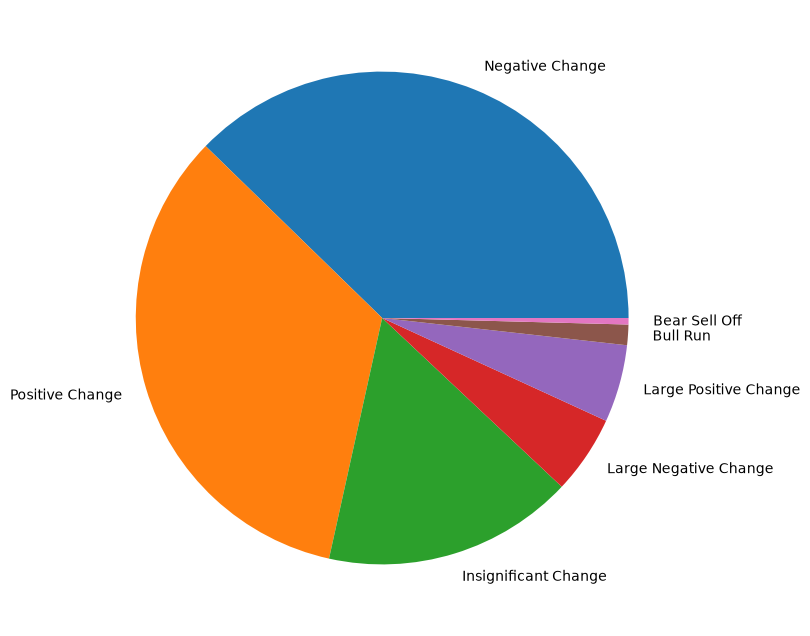

In [42]:
plt.figure(figsize = (8, 8))
trend_summary.plot(kind = 'pie', y = 'Trend')

In [43]:
tataelxsi_df.set_index(['Date'], inplace = True)
tataelxsi_df

,Open,High,Low,Close,Volume,Daily Return,Trend
Date,,,,,,,
2021-01-01,1728.037045,1758.040944,1722.411314,1751.430664,254672,0.000000,Insignificant Change
2021-01-04,1763.619588,1776.793219,1750.305405,1763.760254,400879,0.703972,Positive Change
2021-01-05,1767.417240,1847.115099,1763.760491,1835.769897,1115371,4.082734,Large Positive Change
2021-01-06,1844.301961,1892.448814,1825.690192,1870.180298,770176,1.874440,Positive Change
2021-01-07,1887.948280,1908.013293,1865.867242,1874.258911,349121,0.218087,Insignificant Change
...,...,...,...,...,...,...,...
2026-09-11,3400.199951,3411.000000,3373.699951,3383.000000,112924,-0.762687,Negative Change
2026-09-14,3383.000000,3383.000000,3383.000000,3383.000000,0,0.000000,Insignificant Change
2026-09-15,3450.000000,3532.100098,3418.100098,3440.000000,424602,1.684895,Positive Change


In [44]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "uninstall", "-y", "plotly"
])

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "plotly==4.14.3"
])

Found existing installation: plotly 4.14.3
Uninstalling plotly-4.14.3:
  Successfully uninstalled plotly-4.14.3
  Using cached plotly-4.14.3-py2.py3-none-any.whl.metadata (7.6 kB)
Using cached plotly-4.14.3-py2.py3-none-any.whl (13.2 MB)



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


0

In [45]:
import plotly
# Compatibility fix for NumPy 2.x and older Plotly/Cufflinks
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

import cufflinks

print("Plotly:", plotly.__version__)
print("Cufflinks:", cufflinks.__version__)

Plotly: 4.14.3
Cufflinks: 0.17.3


In [46]:
import cufflinks as cf

cf.go_offline()

figure = cf.QuantFig(
    tataelxsi_df,
    title='Tata Elxsi Limited (TATAELXSI) Candlestick Chart',
    name='TATAELXSI'
)

figure.add_sma(
    periods=[14, 21],
    column='Close',
    color=['magenta', 'green']
)

# Compatibility fix for older Cufflinks with newer pandas
if not hasattr(pd.DatetimeIndex, "format"):
    pd.DatetimeIndex.format = lambda self, *args, **kwargs: self.strftime(
        "%Y-%m-%d %H:%M:%S"
    )

import plotly.graph_objects as go

plot = go.Figure()

plot.add_trace(go.Candlestick(
    x=tataelxsi_df.index,
    open=tataelxsi_df["Open"],
    high=tataelxsi_df["High"],
    low=tataelxsi_df["Low"],
    close=tataelxsi_df["Close"],
    name="TATAELXSI",
    increasing_line_color="green",
    decreasing_line_color="red"
))

plot.add_trace(go.Scatter(
    x=tataelxsi_df.index,
    y=tataelxsi_df["Close"].rolling(14).mean(),
    name="SMA 14",
    line=dict(color="magenta")
))

plot.add_trace(go.Scatter(
    x=tataelxsi_df.index,
    y=tataelxsi_df["Close"].rolling(21).mean(),
    name="SMA 21",
    line=dict(color="green")
))

plot.update_layout(
    title="Tata Elxsi Limited (TATAELXSI) Candlestick Chart",
    xaxis_rangeslider_visible=False
)

plot.show()

In [56]:
stocks_df = pd.read_csv('Multi_Stocks - Stocks.csv')
stocks_df = stocks_df.iloc[:-1]

stocks_df

,Date,Tata Elxsi,Persistent,KPI Tech,HCL Tech,Tech Mahindra,LTM,Coforge
0,2021-01-01,1751.431,713.773,713.773,751.726,800.047,3439.957,509.930
1,2021-01-04,1763.760,724.378,724.378,775.373,819.681,3575.768,531.715
2,2021-01-05,1835.770,738.987,738.987,784.033,821.235,3839.858,539.957
3,2021-01-06,1870.180,734.411,734.411,773.633,815.754,3679.498,524.784
4,2021-01-07,1874.259,724.569,724.569,761.256,813.790,3610.686,513.404
...,...,...,...,...,...,...,...,...
1411,2026-09-11,3383.000,5516.000,5516.000,1206.100,1541.000,4275.000,1846.500
1412,2026-09-14,3383.000,5516.000,5516.000,1206.100,1541.000,4275.000,1846.500
1413,2026-09-15,3440.000,5477.500,5477.500,1253.700,1575.900,4346.600,1775.500
1414,2026-09-16,3373.000,5440.000,5440.000,1253.000,1558.000,4233.000,1766.700


In [58]:
daily_returns_df = stocks_df.iloc[:, 1:].pct_change() * 100
daily_returns_df.replace(np.nan, 0, inplace = True)
daily_returns_df

,Tata Elxsi,Persistent,KPI Tech,HCL Tech,Tech Mahindra,LTM,Coforge
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.703939,1.485766,1.485766,3.145694,2.454106,3.948044,4.272155
2,4.082755,2.016765,2.016765,1.116882,0.189586,7.385546,1.550079
3,1.874418,-0.619226,-0.619226,-1.326475,-0.667409,-4.176196,-2.810039
4,0.218107,-1.340122,-1.340122,-1.599854,-0.240759,-1.870146,-2.168511
...,...,...,...,...,...,...,...
1411,-0.762687,0.117978,0.117978,-0.074565,0.996199,-2.263374,0.731002
1412,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1413,1.684895,-0.697970,-0.697970,3.946605,2.264763,1.674854,-3.845112
1414,-1.947674,-0.684619,-0.684619,-0.055835,-1.135859,-2.613537,-0.495635


In [59]:
daily_returns_df.insert(0, "Date", stocks_df['Date'])
daily_returns_df

,Date,Tata Elxsi,Persistent,KPI Tech,HCL Tech,Tech Mahindra,LTM,Coforge
0,2021-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2021-01-04,0.703939,1.485766,1.485766,3.145694,2.454106,3.948044,4.272155
2,2021-01-05,4.082755,2.016765,2.016765,1.116882,0.189586,7.385546,1.550079
3,2021-01-06,1.874418,-0.619226,-0.619226,-1.326475,-0.667409,-4.176196,-2.810039
4,2021-01-07,0.218107,-1.340122,-1.340122,-1.599854,-0.240759,-1.870146,-2.168511
...,...,...,...,...,...,...,...,...
1411,2026-09-11,-0.762687,0.117978,0.117978,-0.074565,0.996199,-2.263374,0.731002
1412,2026-09-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1413,2026-09-15,1.684895,-0.697970,-0.697970,3.946605,2.264763,1.674854,-3.845112
1414,2026-09-16,-1.947674,-0.684619,-0.684619,-0.055835,-1.135859,-2.613537,-0.495635


In [62]:
plot_financial_data(stocks_df, 'Stocks Closing Prices [$]')

In [63]:
plot_financial_data(daily_returns_df, 'Stocks Percentage Daily Returns [%]')

In [70]:
fig = px.histogram(daily_returns_df.drop(columns = ['Date']))
fig.update_layout({'plot_bgcolor': "white"})


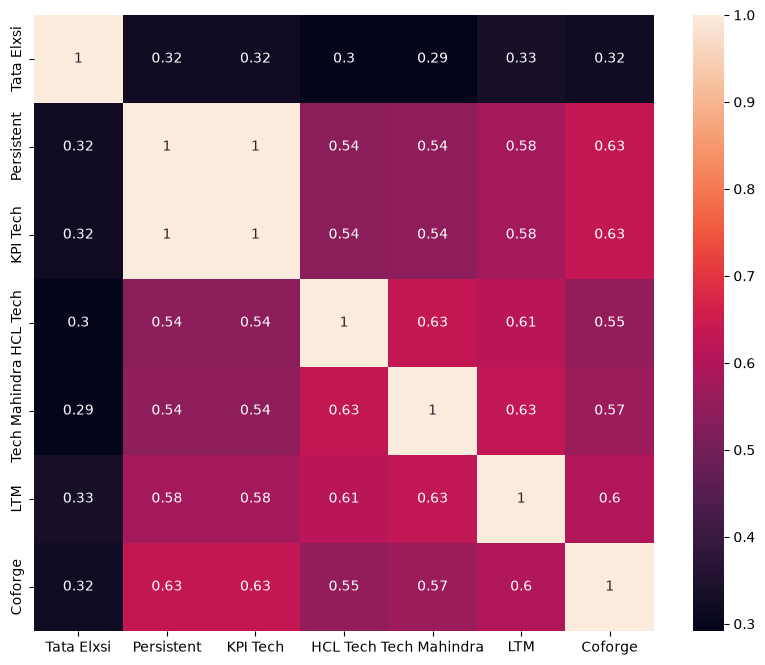

In [71]:
plt.figure(figsize = (10, 8))
sns.heatmap(daily_returns_df.drop(columns = ['Date']).corr(), annot = True);

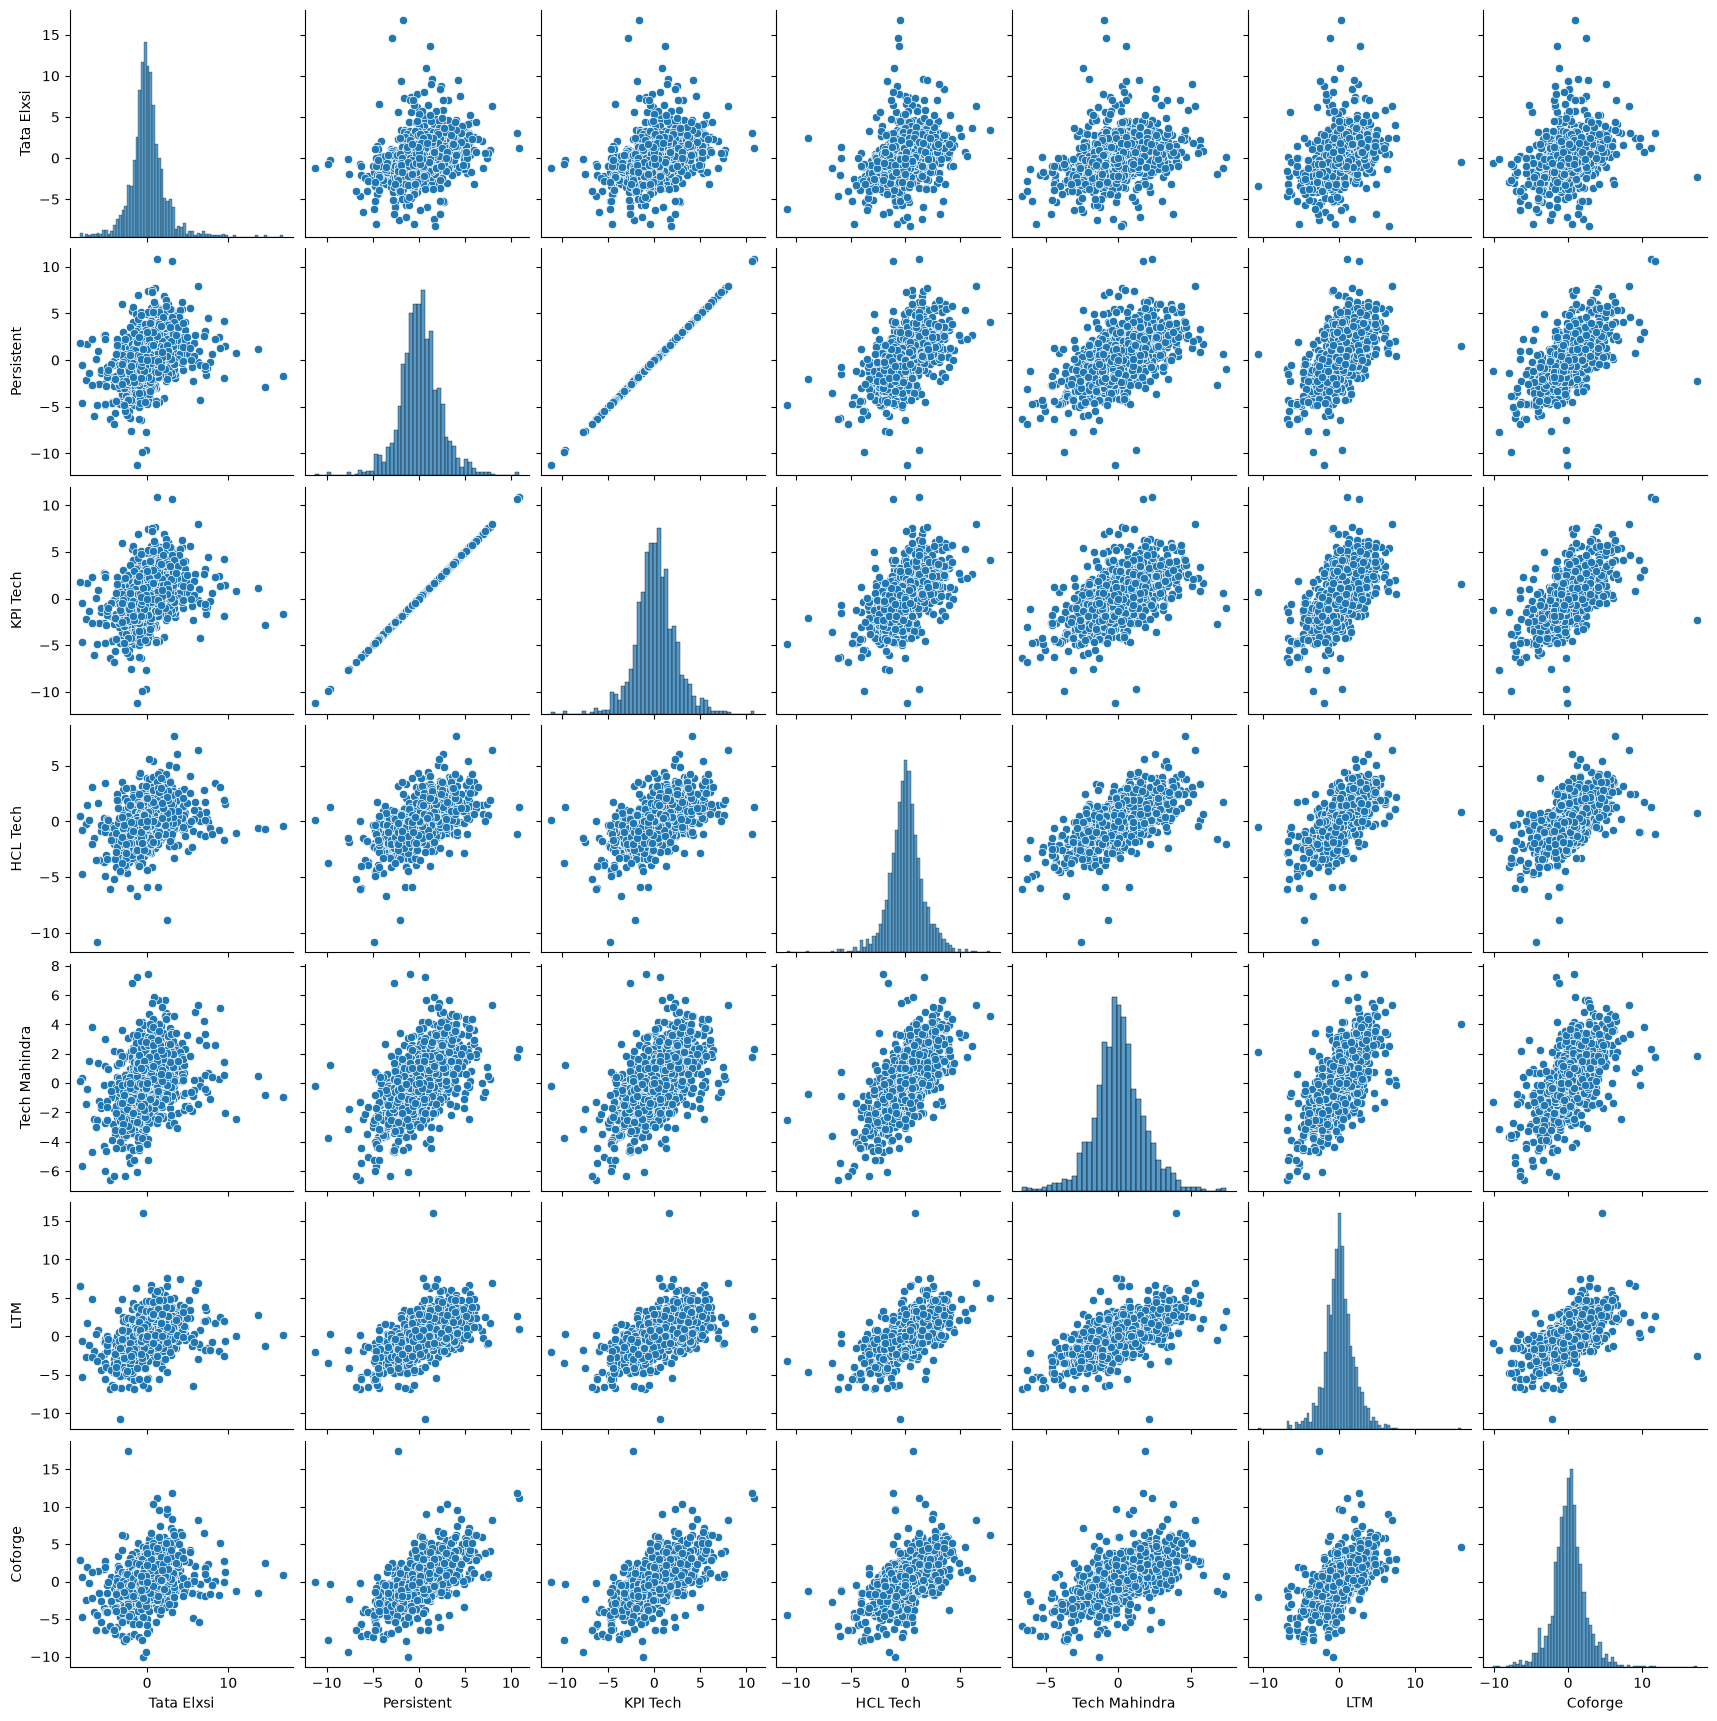

In [72]:
sns.pairplot(daily_returns_df);

In [73]:
def price_scaling(raw_prices_df):
    scaled_prices_df = raw_prices_df.copy()
    for i in raw_prices_df.columns[1:]:
          scaled_prices_df[i] = raw_prices_df[i]/raw_prices_df[i][0]
    return scaled_prices_df

In [75]:
price_scaling(stocks_df)

,Date,Tata Elxsi,Persistent,KPI Tech,HCL Tech,Tech Mahindra,LTM,Coforge
0,2021-01-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2021-01-04,1.007039,1.014858,1.014858,1.031457,1.024541,1.039480,1.042722
2,2021-01-05,1.048154,1.035325,1.035325,1.042977,1.026483,1.116252,1.058885
3,2021-01-06,1.067801,1.028914,1.028914,1.029142,1.019633,1.069635,1.029129
4,2021-01-07,1.070130,1.015125,1.015125,1.012677,1.017178,1.049631,1.006813
...,...,...,...,...,...,...,...,...
1411,2026-09-11,1.931563,7.727947,7.727947,1.604441,1.926137,1.242748,3.621085
1412,2026-09-14,1.931563,7.727947,7.727947,1.604441,1.926137,1.242748,3.621085
1413,2026-09-15,1.964108,7.674008,7.674008,1.667762,1.969759,1.263562,3.481850
1414,2026-09-16,1.925854,7.621471,7.621471,1.666831,1.947386,1.230539,3.464593
